In [1]:
from MakeHam import *
from Helpers import *
import matplotlib.pyplot as plt
from math import factorial
from scipy.sparse.linalg import eigsh
from SKQD import *

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [69]:
# H = make_hermitian_sparse_random_from_qubits(4, 0.5)
H, psi = make_sparse_ground_state_hamiltonian_from_qubits(8, 80, ground_energy=-5, gap =1, add_excited_randomness=True, excited_random_strength=1)

In [70]:
H.shape

(256, 256)

In [71]:
correct_energy, correct_state = eigsh(H, k=1, which='SA')

In [72]:
# Sparsity of the correct ground state
amps = np.abs(correct_state[:, 0]) ** 2
sparsity = np.sum(amps > 1e-4) / len(amps)
print(f"Sparsity of the correct ground state: {sparsity:.4f}")

Sparsity of the correct ground state: 0.3125


In [73]:
np.argmax(amps)

np.int64(187)

In [74]:
n_steps = 4
initial = 187

initial_state = np.zeros(H.shape[0])
initial_state[initial] = 1

# Print overlap with correct state
print(f"Initial overlap with correct state: {np.abs(np.dot(correct_state[:, 0].conj(), initial_state)):.4f}")

skqd_list0001 = do_skqd(H, n_steps, t = 0.01, initial=initial)
skqd_list001 = do_skqd(H, n_steps, t = 0.01, initial=initial)
skqd_list01 = do_skqd(H, n_steps, t = 0.1, initial=initial)
skqd_list02 = do_skqd(H, n_steps, t = 0.2, initial=initial)
skqd_list03 = do_skqd(H, n_steps, t = 0.3, initial=initial)
skqd_list04 = do_skqd(H, n_steps, t = 0.4, initial=initial)
skqd_list05 = do_skqd(H, n_steps, t = 0.5, initial=initial)
skqd_list06 = do_skqd(H, n_steps, t = 0.6, initial=initial)
skqd_list07 = do_skqd(H, n_steps, t = 0.7, initial=initial)
skqd_list08 = do_skqd(H, n_steps, t = 0.8, initial=initial)
skqd_list09 = do_skqd(H, n_steps, t = 0.9, initial=initial)
skqd_list10 = do_skqd(H, n_steps, t = 1.0, initial=initial)

Initial overlap with correct state: 0.2479


100%|██████████| 4/4 [00:00<00:00, 800.78it/s]

No more indices left to sample.


100%|██████████| 4/4 [00:00<00:00, 778.16it/s]


No more indices left to sample.


...

No more indices left to sample.


100%|██████████| 4/4 [00:00<00:00, 811.43it/s]


No more indices left to sample.


100%|██████████| 4/4 [00:00<00:00, 812.18it/s]

No more indices left to sample.


In [75]:
skqd_path01 = get_one_path(H, skqd_list01)
skqd_path02 = get_one_path(H, skqd_list02)
skqd_path03 = get_one_path(H, skqd_list03)
skqd_path04 = get_one_path(H, skqd_list04)
skqd_path05 = get_one_path(H, skqd_list05)
skqd_path06 = get_one_path(H, skqd_list06)
skqd_path07 = get_one_path(H, skqd_list07)
skqd_path08 = get_one_path(H, skqd_list08)
skqd_path09 = get_one_path(H, skqd_list09)
skqd_path10 = get_one_path(H, skqd_list10)
skqd_path001 = get_one_path(H, skqd_list001)
skqd_path0001 = get_one_path(H, skqd_list0001)

In [76]:
Paths = get_all_paths(H, 100, initial)

Computing paths: 100%|██████████| 100/100 [00:57<00:00,  1.74it/s]


In [77]:
Paths.shape

(100, 256)

100


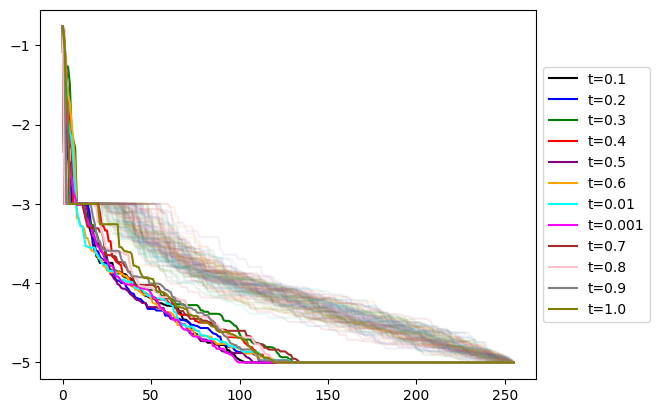

In [78]:
i = 0
for path in Paths:
    plt.plot(path, alpha=0.1)
    i += 1
plt.plot(skqd_path01, label='t=0.1', color='black')
plt.plot(skqd_path02, label='t=0.2', color='blue')
plt.plot(skqd_path03, label='t=0.3', color='green')
plt.plot(skqd_path04, label='t=0.4', color='red')
plt.plot(skqd_path05, label='t=0.5', color='purple')
plt.plot(skqd_path06, label='t=0.6', color='orange')
plt.plot(skqd_path001, label='t=0.01', color='cyan')
plt.plot(skqd_path0001, label='t=0.001', color='magenta')
plt.plot(skqd_path07, label='t=0.7', color='brown')
plt.plot(skqd_path08, label='t=0.8', color='pink')
plt.plot(skqd_path09, label='t=0.9', color='gray')
plt.plot(skqd_path10, label='t=1.0', color='olive')
# Make legend next to plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
print(i)